# Chapter 06. Probing, Counterfactuals, and Concepts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadi-hadi/hands-on-xai-labs/blob/main/notebooks/ch06-probing-counterfactuals-concepts.ipynb)

Companion notebook for Chapter 06 of *Hands-On Explainable AI*.

**What you'll build:** three representation-level explanations of the Chapter 4 hate-speech specimen. First you'll train a logistic-regression *probe* on every layer's `[CLS]` vector to find where in the network the hate/not-hate decision becomes linearly readable, with a shuffled-label control task so high accuracy can't fool you. Then you'll run a greedy *counterfactual* search that flips the model's label with the fewest possible one-token edits, tracing each tweet's probability across the decision boundary. Finally you'll distill a *concept direction* (a single vector separating hateful from neutral activations) and test how well it classifies held-out tweets it never saw.

This lab is part of *Hands-On Explainable AI: Interpreting, Evaluating, and Trusting Large Language Models* by [Hadi Mohammadi](https://mohammadi.cv). Code is MIT licensed; the repository and citation info live at [hands-on-xai-labs](https://github.com/mohammadi-hadi/hands-on-xai-labs) (DOI: [10.5281/zenodo.21804605](https://doi.org/10.5281/zenodo.21804605)).

In [1]:
%%capture
import importlib.util
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    %pip install -q transformers==4.57.* datasets==3.6.* scikit-learn==1.9.*

In [2]:
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Smoke mode: CI sets BOOK_SMOKE=1 to swap in tiny data + tiny search budgets
SMOKE = os.environ.get("BOOK_SMOKE") == "1"
DEVICE = os.environ.get("BOOK_DEVICE") or (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

_style = Path("../styles/book.mplstyle")
if _style.exists():
    plt.style.use(_style)
INK, RUST, TEAL, AMBER, ROSE, STONE = "#1A1C1E", "#9A3412", "#0D9488", "#F59E0B", "#E11D48", "#A8A29E"

N_TWEETS = 200 if SMOKE else 600      # tweets we collect hidden states for
CF_N = 3 if SMOKE else 6              # counterfactual search examples
CF_MAX_EDITS = 3 if SMOKE else 5      # greedy edit budget per tweet
CF_MAX_WORDS = 12 if SMOKE else 18    # keep the candidate pool affordable
WALL = {}                             # wall-clock ledger, printed at the end
print(f"device={DEVICE} smoke={SMOKE} n_tweets={N_TWEETS}")

device=cpu smoke=False n_tweets=600


> **Content note.** This chapter reuses the Part II specimen: a hate-speech classifier fine-tuned on HatEval (SemEval-2019 Task 5), which targets hate against **women and immigrants**. Real tweets printed below contain slurs and abusive language. We keep them verbatim because sanitized data would change exactly the token-level behavior this lab measures.

## 1. Load the specimen

Same classifier as Chapters 4 and 5: `distilbert-base-uncased` fine-tuned on `tweet_eval/hate` (validation macro-F1 0.676). We reuse it because probing only makes sense against a model whose *input-level* explanations you already know. This chapter asks what its *representations* know, which is a different question.

On Colab (or any fresh clone) the Chapter 4 checkpoint is absent, so `get_specimen()` quick-trains a smaller stand-in; your numbers will differ from the printed ones while every probe below still runs.

In [3]:
SPECIMEN_DIR = Path("../models/ch04-specimen")


def get_specimen():
    """Load the Chapter 4 hate/sexism specimen; quick-train a small stand-in if absent (keeps this notebook standalone on Colab)."""
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    if SPECIMEN_DIR.exists():
        tok = AutoTokenizer.from_pretrained(SPECIMEN_DIR)
        mdl = AutoModelForSequenceClassification.from_pretrained(SPECIMEN_DIR)
    else:
        # Quick-train fallback: bert-mini on tweet_eval 'hate', saved so later runs skip this.
        from datasets import load_dataset
        base = "prajjwal1/bert-mini"
        tok = AutoTokenizer.from_pretrained(base)
        mdl = AutoModelForSequenceClassification.from_pretrained(
            base, num_labels=2,
            id2label={0: "not-hate", 1: "hate"}, label2id={"not-hate": 0, "hate": 1},
        )
        ds = load_dataset("tweet_eval", "hate", split="train").shuffle(seed=SEED).select(range(1500))
        enc = tok(ds["text"], truncation=True, max_length=96, padding=True, return_tensors="pt")
        y = torch.tensor(ds["label"])
        mdl.to(DEVICE).train()
        opt = torch.optim.AdamW(mdl.parameters(), lr=3e-5)
        order = np.arange(len(y))
        for _ in range(2):
            np.random.shuffle(order)
            for i in range(0, len(order), 32):
                b = order[i : i + 32]
                batch = {k: v[b].to(DEVICE) for k, v in enc.items()}
                loss = mdl(**batch, labels=y[b].to(DEVICE)).loss
                loss.backward()
                opt.step()
                opt.zero_grad()
        SPECIMEN_DIR.mkdir(parents=True, exist_ok=True)
        mdl.save_pretrained(SPECIMEN_DIR)
        tok.save_pretrained(SPECIMEN_DIR)
    mdl.to(DEVICE).eval()
    return tok, mdl


tok, mdl = get_specimen()
N_LAYERS = mdl.config.num_hidden_layers + 1  # embedding output + each transformer block
print(f"specimen: {mdl.config.architectures[0]}, {mdl.config.num_hidden_layers} blocks "
      f"-> {N_LAYERS} hidden-state layers, hidden size {mdl.config.dim if hasattr(mdl.config, 'dim') else mdl.config.hidden_size}")

specimen: DistilBertForSequenceClassification, 6 blocks -> 7 hidden-state layers, hidden size 768


## 2. Data and hidden states

We probe on the HatEval **validation** split: tweets the specimen never trained on, so a probe can't succeed by reading memorized examples. We deliberately avoid the HatEval *test* split: it is topic-shifted (Chapter 4 measured the collapse honestly: the specimen calls ~96% of it hate, accuracy 0.460 vs 0.676 on validation), and a warped yardstick would contaminate every probe below. One forward pass with `output_hidden_states=True` gives every layer's activations at once; we keep the `[CLS]` vector per layer because that is the exact position the classification head reads.

In [4]:
# Small inline fallback so the notebook survives fully offline (labels: 1 = hate, 0 = not).
FALLBACK_TWEETS = [
    ("women like her should shut up and stay in the kitchen where they belong", 1),
    ("another boatload of illegals invading our country send them all back", 1),
    ("she is a dumb hoe like every other woman with an opinion", 1),
    ("immigrants are parasites draining this nation dry deport them", 1),
    ("typical stupid bitch thinks she deserves equal pay lol", 1),
    ("refugees are criminals flooding in to rob decent people", 1),
    ("no woman should ever be allowed to lead anything", 1),
    ("these migrants breed like rats and ruin every neighborhood", 1),
    ("shut your mouth you worthless skank nobody asked you", 1),
    ("build the wall and keep every last one of them out", 1),
    ("girls who dress like that are asking for whatever happens", 1),
    ("this country is full go home you are not welcome here", 1),
    ("the new immigration policy will be debated in parliament this week", 0),
    ("my grandmother makes the best lasagna in the entire world", 0),
    ("congrats to the women's soccer team on their championship win", 0),
    ("refugee students graduated top of the class this spring", 0),
    ("looking forward to the weekend hiking trip with friends", 0),
    ("the documentary about migration patterns of birds was fascinating", 0),
    ("she gave a brilliant keynote on machine learning yesterday", 0),
    ("volunteers welcomed the new families with food and clothes", 0),
    ("traffic was terrible this morning but the podcast was great", 0),
    ("my neighbor fixed my bike for free what a kind person", 0),
    ("the bakery on fifth street finally reopened today", 0),
    ("reading a wonderful novel about a family crossing three generations", 0),
]

try:
    from datasets import load_dataset
    _ds = load_dataset("tweet_eval", "hate", split="validation").shuffle(seed=SEED)
    texts = list(_ds["text"][:N_TWEETS])
    labels = np.array(_ds["label"][:N_TWEETS])
    data_source = "tweet_eval/hate validation split"
except Exception as exc:  # offline fallback
    texts = [t for t, _ in FALLBACK_TWEETS]
    labels = np.array([lab for _, lab in FALLBACK_TWEETS])
    data_source = f"inline fallback ({type(exc).__name__})"

print(f"{len(texts)} tweets from {data_source}; hate rate {labels.mean():.2f}")

600 tweets from tweet_eval/hate validation split; hate rate 0.42


In [5]:
@torch.no_grad()
def cls_states(some_texts, batch_size=32, max_len=96):
    """[CLS] hidden state at every layer -> array (n_texts, n_layers, hidden)."""
    chunks = []
    for i in range(0, len(some_texts), batch_size):
        enc = tok(some_texts[i : i + batch_size], truncation=True, max_length=max_len,
                  padding=True, return_tensors="pt").to(DEVICE)
        out = mdl(**enc, output_hidden_states=True)
        chunks.append(torch.stack([h[:, 0, :] for h in out.hidden_states], dim=1).float().cpu())
    return torch.cat(chunks).numpy()


t0 = time.monotonic()
X = cls_states(texts)
WALL["hidden-state extraction"] = time.monotonic() - t0
print(f"hidden states {X.shape} (tweets, layers, hidden) in {WALL['hidden-state extraction']:.1f}s")

hidden states (600, 7, 768) (tweets, layers, hidden) in 2.1s


## 3. Layer-wise probing, with a control task

A probe is the simplest possible experiment: freeze the model, train a logistic regression on one layer's activations, and ask *is the label linearly readable here?* The classic pitfall is that a probe with enough capacity can decode almost anything from anywhere; high accuracy does **not** mean the model uses that information. Hewitt & Liang's fix is a **control task**: run the identical probe on the same activations but with shuffled labels. What it scores there is pure memorization/noise-fitting. **Selectivity** = task accuracy − control accuracy: what the probe learned about the task, above what it could fake.

(Honest adaptation note: Hewitt & Liang define controls over word *types* for structural probes; for sentence-level classification with unseen test sentences, our shuffled-label control lands near the shuffled majority rate. It bounds probe capacity rather than type memorization. We keep it because it is the right habit: never report probe accuracy without a control number next to it.)

In [6]:
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(texts))
n_tr = int(0.75 * len(texts))
tr, te = perm[:n_tr], perm[n_tr:]


def probe_accuracies(feats, y, tr, te):
    """One logistic-regression probe per layer; returns held-out accuracy per layer."""
    accs = []
    for layer in range(feats.shape[1]):
        clf = LogisticRegression(max_iter=2000)
        clf.fit(feats[tr, layer], y[tr])
        accs.append(clf.score(feats[te, layer], y[te]))
    return np.array(accs)


t0 = time.monotonic()
task_acc = probe_accuracies(X, labels, tr, te)
control_labels = rng.permutation(labels)  # control task: same inputs, shuffled labels
control_acc = probe_accuracies(X, control_labels, tr, te)
selectivity = task_acc - control_acc
WALL["probing (task + control)"] = time.monotonic() - t0

majority = max(labels[te].mean(), 1 - labels[te].mean())
probe_df = pd.DataFrame({
    "layer": np.arange(N_LAYERS),
    "task acc": task_acc.round(3),
    "control acc": control_acc.round(3),
    "selectivity": selectivity.round(3),
})
print(probe_df.to_string(index=False))
print(f"\nmajority-class baseline {majority:.3f} | best task layer {task_acc.argmax()} "
      f"({task_acc.max():.3f}) in {WALL['probing (task + control)']:.1f}s")

 layer  task acc  control acc  selectivity
     0     0.593        0.600       -0.007
     1     0.707        0.513        0.193
     2     0.673        0.507        0.167
     3     0.720        0.527        0.193
     4     0.673        0.593        0.080
     5     0.707        0.560        0.147
     6     0.713        0.560        0.153

majority-class baseline 0.593 | best task layer 3 (0.720) in 0.2s


## 4. A second probe: different knowledge lives at different depths

The hate *decision* is an abstract, task-level property. Compare it against a pure **surface** property: is the tweet longer than the median (a binary length bucket)? Length needs no semantics at all: as soon as attention lets `[CLS]` pool over the sequence, it should be trivially readable. Watch two things: *where* each curve peaks, and what happens at layer 0.

Layer 0 is a spoiler worth stating up front: the embedding-layer `[CLS]` vector is the same for every input (token embedding of `[CLS]` + position 0; the tweet hasn't been mixed in yet), so **every** layer-0 probe can only score the majority baseline. Information reaches `[CLS]` exclusively through attention.

In [7]:
word_counts = np.array([len(t.split()) for t in texts])
length_labels = (word_counts > np.median(word_counts)).astype(int)  # surface target: long vs short
length_acc = probe_accuracies(X, length_labels, tr, te)
length_majority = max(length_labels[te].mean(), 1 - length_labels[te].mean())
print(f"length-bucket base rate {length_labels.mean():.2f} (median {np.median(word_counts):.0f} words) "
      f"| majority baseline {length_majority:.3f}")
print("length probe acc by layer:", np.round(length_acc, 3))
print(f"length peak layer {length_acc.argmax()} vs hate peak layer {task_acc.argmax()}")

length-bucket base rate 0.49 (median 21 words) | majority baseline 0.507
length probe acc by layer: [0.493 0.88  0.907 0.893 0.887 0.867 0.84 ]
length peak layer 2 vs hate peak layer 3


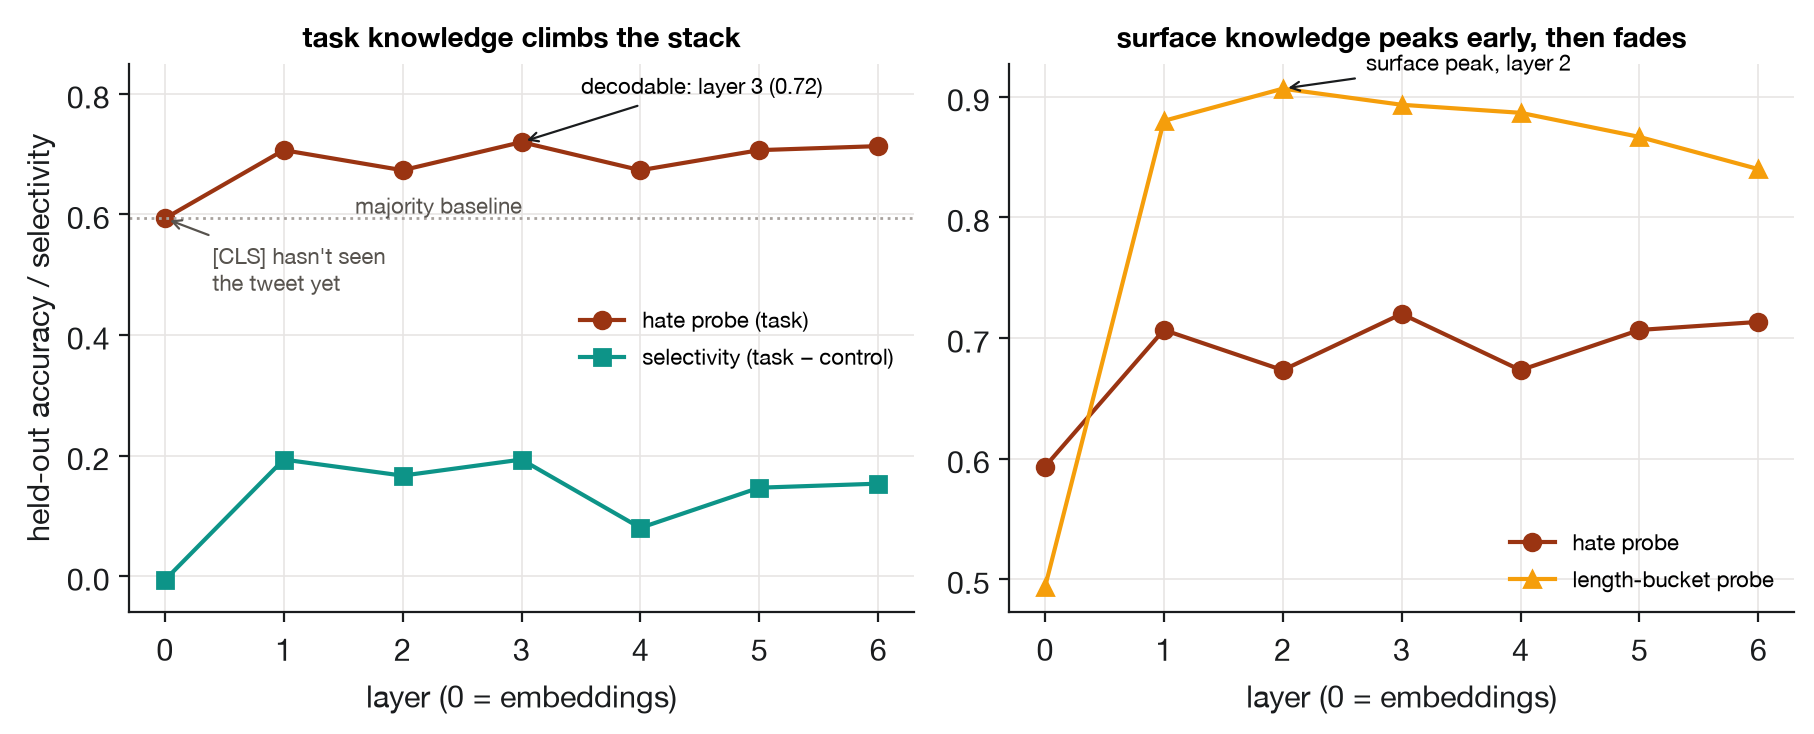

In [8]:
#| label: fig-probe-by-layer
#| fig-cap: "Layer-wise probes: the hate decision peaks mid-stack (left); tweet length peaks immediately and fades (right). At layer 0 the [CLS] vector is input-independent, so probes collapse to the majority baseline."
#| fig-alt: "Two line plots of probe accuracy by layer: the hate decision becomes decodable after layer 0 and peaks mid-stack, while the tweet-length control peaks immediately and fades."
layers = np.arange(N_LAYERS)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.2, 3.8), sharex=True)

ax1.plot(layers, task_acc, color=RUST, marker="o", label="hate probe (task)")
ax1.plot(layers, selectivity, color=TEAL, marker="s", label="selectivity (task − control)")
ax1.axhline(majority, color=STONE, ls=":", lw=1)
GRAPHITE = "#57534E"  # secondary text
ax1.text(1.6, majority + 0.008, "majority baseline", color=GRAPHITE, fontsize=8)
best = int(task_acc.argmax())
ax1.set_ylim(-0.06, 0.85)
ax1.annotate(f"decodable: layer {best} ({task_acc[best]:.2f})",
             xy=(best, task_acc[best]), xytext=(best + 0.5, 0.80),
             fontsize=8, arrowprops={"arrowstyle": "->", "color": INK, "linewidth": 0.8})
ax1.annotate("[CLS] hasn't seen\nthe tweet yet",
             xy=(0, task_acc[0]), xytext=(0.4, task_acc[0] - 0.12),
             fontsize=8, color=GRAPHITE,
             arrowprops={"arrowstyle": "->", "color": GRAPHITE, "linewidth": 0.8})
ax1.set_xlabel("layer (0 = embeddings)")
ax1.set_ylabel("held-out accuracy / selectivity")
ax1.set_title("task knowledge climbs the stack", fontsize=10)
ax1.legend(fontsize=8, loc="center right")

ax2.plot(layers, task_acc, color=RUST, marker="o", label="hate probe")
ax2.plot(layers, length_acc, color=AMBER, marker="^", label="length-bucket probe")
lpeak = int(length_acc.argmax())
ax2.annotate(f"surface peak, layer {lpeak}",
             xy=(lpeak, length_acc[lpeak]), xytext=(lpeak + 0.7, length_acc[lpeak] + 0.015),
             fontsize=8, arrowprops={"arrowstyle": "->", "color": INK, "linewidth": 0.8})
ax2.set_xlabel("layer (0 = embeddings)")
ax2.set_title("surface knowledge peaks early, then fades", fontsize=10)
ax2.legend(fontsize=8, loc="lower right")

for ax in (ax1, ax2):
    ax.set_xticks(layers)
fig.tight_layout()
plt.show()

Read the two panels together: the task curve is flat at the majority baseline at layer 0 (the `[CLS]` slot is still a constant vector), jumps as soon as attention pools the tweet in, and peaks mid-stack, while the length probe peaks *immediately* (layer 1–2, ≈0.9) and then **decays** through the upper layers. The network is not "forgetting" length; it is spending its `[CLS]` capacity on what the fine-tuning loss pays for. Different knowledge, different depths, and only the selectivity line tells you the task numbers aren't probe memorization.

## 5. Counterfactuals: the minimal edit that flips the label

A counterfactual explanation answers *"what is the smallest change that would have changed the decision?"*, often more actionable than a saliency map. We implement the bare-metal version: greedy search over one-token edits (delete a word, or replace it with a neutral word), always taking the edit that lowers `p(hate)` most, until the label flips or the budget runs out. Polyjuice and GPT-generated counterfactuals are fluent upgrades of exactly this loop; the mechanics are identical.

In [9]:
@torch.no_grad()
def p_hate(some_texts, batch_size=128, max_len=96):
    out = []
    for i in range(0, len(some_texts), batch_size):
        enc = tok(some_texts[i : i + batch_size], truncation=True, max_length=max_len,
                  padding=True, return_tensors="pt").to(DEVICE)
        out.append(torch.softmax(mdl(**enc).logits, dim=-1)[:, 1].cpu())
    return torch.cat(out).numpy()


NEUTRAL_POOL = ["person", "people", "friend", "neighbor", "someone",
                "good", "kind", "calm", "fine", "thing"]


def greedy_flip(text, max_edits=CF_MAX_EDITS):
    """Greedy one-token edits (delete or neutral substitute) until p(hate) < 0.5."""
    cur = text.split()
    traj = [float(p_hate([text])[0])]
    edits = []
    for _ in range(max_edits):
        if traj[-1] < 0.5:
            break
        cands, descs = [], []
        for i, w in enumerate(cur):
            if len(cur) > 3:
                cands.append(cur[:i] + cur[i + 1 :])
                descs.append(f"drop '{w}'")
            for sub in NEUTRAL_POOL:
                if sub != w.lower():
                    cands.append(cur[:i] + [sub] + cur[i + 1 :])
                    descs.append(f"'{w}'→'{sub}'")
        probs = p_hate([" ".join(c) for c in cands])
        j = int(probs.argmin())
        if probs[j] >= traj[-1]:
            break  # no single edit helps any more
        cur = cands[j]
        edits.append(descs[j])
        traj.append(float(probs[j]))
    return " ".join(cur), edits, traj

In [10]:
# Pick confidently-hate-classified held-out tweets, short enough to search affordably.
te_texts = [texts[i] for i in te]
te_probs = p_hate(te_texts)
order = np.argsort(-te_probs)
picked = [i for i in order if len(te_texts[i].split()) <= CF_MAX_WORDS][:CF_N]
if len(picked) < CF_N:  # tiny fallback data may lack short tweets
    picked = list(order[:CF_N])

t0 = time.monotonic()
cf_rows, cf_trajs = [], []
for i in picked:
    text = te_texts[i]
    edited, edits, traj = greedy_flip(text)
    cf_rows.append({
        "tweet": text[:52] + ("…" if len(text) > 52 else ""),
        "gold": int(labels[te][i]),
        "p₀": round(traj[0], 3),
        "p_end": round(traj[-1], 3),
        "edits": len(edits),
        "flipped": traj[-1] < 0.5,
        "edit path": "; ".join(edits) if edits else "none",
    })
    cf_trajs.append(traj)
WALL["counterfactual search"] = time.monotonic() - t0

cf_df = pd.DataFrame(cf_rows)
print(cf_df.to_string(index=False))
flips = sum(r["flipped"] for r in cf_rows)
mean_edits = np.mean([r["edits"] for r in cf_rows if r["flipped"]]) if flips else float("nan")
print(f"\nflipped {flips}/{len(cf_rows)} | mean edits to flip {mean_edits:.1f} "
      f"| search took {WALL['counterfactual search']:.1f}s")

                                                tweet  gold    p₀  p_end  edits  flipped                                                                               edit path
         @user Thinking #WhiteGenocide #BuildThatWall     1 0.907  0.196      1     True                                                                   drop '#BuildThatWall'
@user We have our own invasion issues with Mexicans.…     1 0.906  0.483      1     True                                                               '#BuildThatWall'→'friend'
@user dats right bitch ass fag cunt slut dumb fucken…     1 0.893  0.797      5    False       'bitch'→'good'; 'bitch,'→'friend'; 'fucken'→'friend'; drop 'fuck'; 'ass'→'friend'
@user Yea that fucking ass hole mother fucking bitch…     1 0.873  0.411      5     True 'bitch!'→'friend'; 'Yea'→'kind'; 'fucking'→'friend'; 'fucking'→'people'; 'ass'→'friend'
Stfu, theres a million people without dads, youre ri…     1 0.861  0.473      4     True                      'bitc

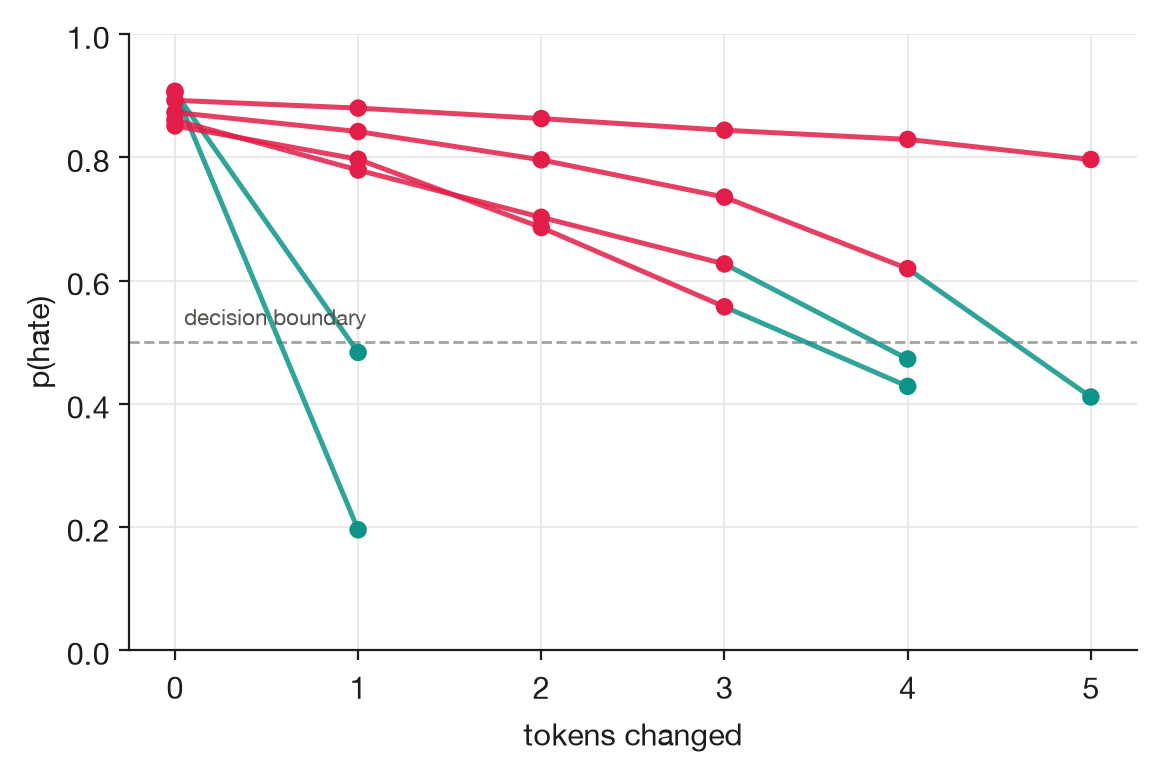

In [11]:
#| label: fig-counterfactual-edits
#| fig-cap: "Greedy one-token edits walk each tweet toward the decision boundary. Segments turn from rose to teal where p(hate) crosses 0.5; an all-rose path failed to flip within budget."
#| fig-alt: "Probability traces of greedy one-token edits walking tweets toward the decision boundary, changing color where p(hate) crosses 0.5; one slur-dense tweet never crosses."
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.axhline(0.5, color=STONE, ls="--", lw=1)
GRAPHITE = "#57534E"  # secondary text
ax.text(0.05, 0.52, "decision boundary", color=GRAPHITE, fontsize=8, va="bottom")
for traj in cf_trajs:
    xs = np.arange(len(traj))
    for k in range(len(traj) - 1):
        seg_color = ROSE if traj[k + 1] >= 0.5 else TEAL
        ax.plot(xs[k : k + 2], traj[k : k + 2], color=seg_color, lw=1.8, alpha=0.85, zorder=2)
    pt_colors = [ROSE if p >= 0.5 else TEAL for p in traj]
    ax.scatter(xs, traj, c=pt_colors, s=28, zorder=3)
ax.set_xlabel("tokens changed")
ax.set_ylabel("p(hate)")
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(max(len(t) for t in cf_trajs)))
plt.show()

In our full run one tweet refused to flip: five one-token edits only brought it from p(hate) 0.89 to 0.80, because its signal is spread across many slurs: no *single* token carries the decision. Minimal-edit counterfactuals are a search problem, and honest search sometimes fails; report the failures, they describe the model too.

**Bridge to Chapter 7:** an attacker runs this same loop with *your explanation* as the ranking: swap "which edit lowers p(hate) most" for "which edit the saliency map points at" and this counterfactual generator becomes an adversarial-attack generator. Same code, different intent.

## 6. A concept direction (CAV-lite)

If "hatefulness" is linearly decodable at the best probing layer, there should be a single *direction* in activation space that separates it. We take the cheapest possible version (the mean-difference vector between hateful and neutral `[CLS]` activations on the probe-training tweets) and project **held-out** tweets onto it. This is a concept activation vector (CAV) in spirit; the score below is how well one 768-dimensional arrow, fit with zero gradient steps, classifies unseen tweets.

In [12]:
best_layer = int(task_acc.argmax())
Xb = X[:, best_layer, :]
mu_hate = Xb[tr][labels[tr] == 1].mean(axis=0)
mu_neutral = Xb[tr][labels[tr] == 0].mean(axis=0)
concept_v = mu_hate - mu_neutral
concept_v = concept_v / np.linalg.norm(concept_v)
midpoint = (mu_hate + mu_neutral) / 2

proj = (Xb[te] - midpoint) @ concept_v  # signed distance along the concept direction
from sklearn.metrics import roc_auc_score
concept_auc = roc_auc_score(labels[te], proj)
concept_acc = ((proj > 0).astype(int) == labels[te]).mean()
print(f"concept direction at layer {best_layer}: held-out AUC {concept_auc:.3f}, "
      f"sign-rule accuracy {concept_acc:.3f} (trained probe at same layer: {task_acc[best_layer]:.3f})")

concept direction at layer 3: held-out AUC 0.773, sign-rule accuracy 0.707 (trained probe at same layer: 0.720)


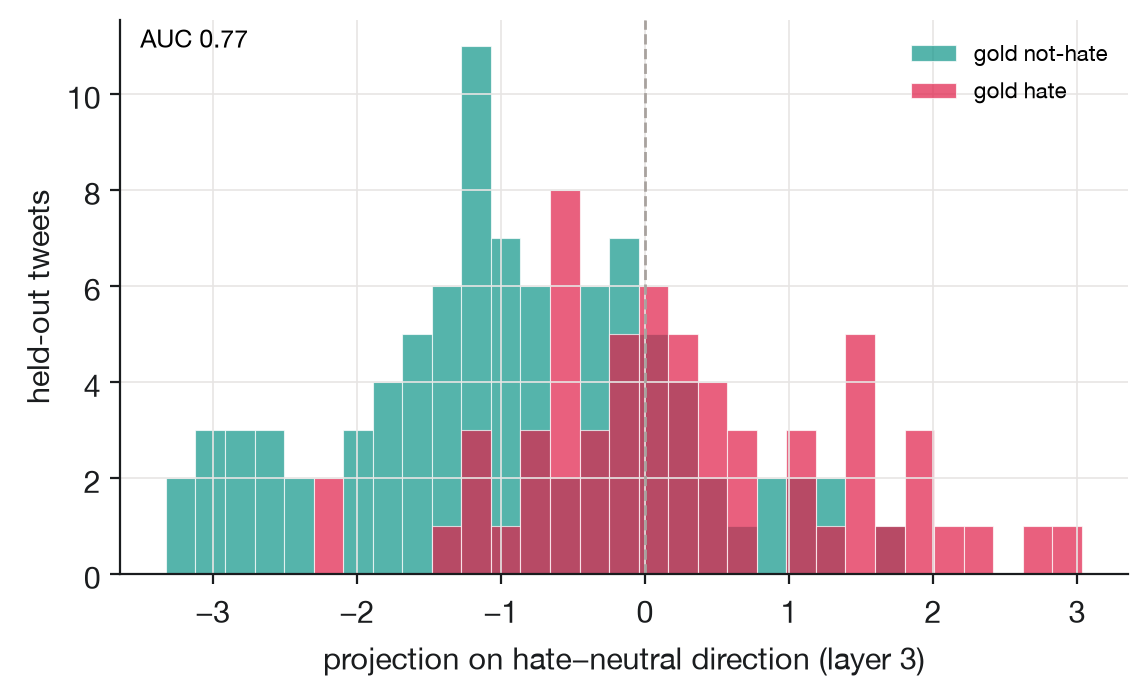

In [13]:
#| label: fig-concept-direction
#| fig-cap: "Held-out tweets projected onto the mean-difference 'hate' direction. One vector, fit with zero gradient steps, separates the classes: AUC 0.773, sign-rule accuracy 0.707 vs the trained probe's 0.720."
#| fig-alt: "Two overlapping histograms of held-out tweets projected onto the mean-difference hate direction: the classes separate with AUC 0.773."
fig, ax = plt.subplots(figsize=(6.5, 3.6))
bins = np.linspace(proj.min(), proj.max(), 32)
ax.hist(proj[labels[te] == 0], bins=bins, color=TEAL, alpha=0.7, edgecolor="white", lw=0.4, label="gold not-hate")
ax.hist(proj[labels[te] == 1], bins=bins, color=ROSE, alpha=0.7, edgecolor="white", lw=0.4, label="gold hate")
ax.axvline(0, color=STONE, ls="--", lw=1)
ax.text(0.02, 0.95, f"AUC {concept_auc:.2f}", transform=ax.transAxes, fontsize=9)
ax.set_xlabel(f"projection on hate−neutral direction (layer {best_layer})")
ax.set_ylabel("held-out tweets")
ax.legend(fontsize=8)
plt.show()

**What full TCAV adds:** we only *read* activations. TCAV (Kim et al., 2018) additionally takes the directional derivative of the prediction along the concept vector (measuring whether the model's output actually *moves* when you push activations toward the concept) and runs the whole thing against many random-concept vectors for a significance test. Our mean-difference arrow shows the concept is *represented*; TCAV asks whether it is *used*. That gap, represented vs. used, is this chapter's core caution, and Chapter 8 turns it into an evaluation protocol.

In [14]:
print("wall-clock summary:")
for k, v in WALL.items():
    print(f"  {k:28s} {v:6.1f}s")

wall-clock summary:
  hidden-state extraction         2.1s
  probing (task + control)        0.2s
  counterfactual search           2.4s


## Now try it on your own data

Probing needs no labels beyond the ones you invent. Pick any concept (sarcasm, formality, mentions-of-money, first-person voice), write ten sentences that have it and ten that don't, and reuse `cls_states` to find which layer of the specimen encodes it. The skeleton below runs as-is with a placeholder concept (*mentions the weather*); replace the two lists with yours.

In [15]:
# TODO: replace these 20 sentences with YOUR concept, 10 that have it, 10 that don't.
CONCEPT_POS = [  # placeholder concept: mentions the weather
    "the storm knocked out power across the whole city",
    "it has been raining nonstop since early this morning",
    "a heatwave is expected to hit the coast this weekend",
    "thick fog delayed every flight out of the airport",
    "the forecast says snow flurries starting around noon",
    "sunshine and a light breeze made the picnic perfect",
    "hail the size of golf balls dented every car outside",
    "humidity this week makes the air feel like soup",
    "a cold front is moving in from the north tonight",
    "thunder rolled across the valley for hours yesterday",
]
CONCEPT_NEG = [
    "the library extended its opening hours this semester",
    "she finally finished the marathon in under four hours",
    "our team shipped the new release two days early",
    "the recipe calls for three eggs and a cup of flour",
    "he plays bass in a jazz trio on friday nights",
    "the museum opened a new wing dedicated to sculpture",
    "my laptop battery dies before lunch every single day",
    "the committee approved the budget after a long debate",
    "she is learning portuguese with a language exchange partner",
    "the bookstore cafe serves the best espresso in town",
]

from sklearn.model_selection import cross_val_score

Xc = cls_states(CONCEPT_POS + CONCEPT_NEG)
yc = np.array([1] * len(CONCEPT_POS) + [0] * len(CONCEPT_NEG))
for layer in range(N_LAYERS):
    scores = cross_val_score(LogisticRegression(max_iter=2000), Xc[:, layer], yc, cv=5)
    print(f"layer {layer}: {scores.mean():.2f} ± {scores.std():.2f}")

# TODO 1: which layer decodes YOUR concept best, earlier or later than the hate decision?
# TODO 2: build the mean-difference direction for your concept (copy Section 6) and project
#         the 600 probing tweets onto it. Do any hate tweets score high on YOUR concept?
# TODO 3: with only 20 examples, the control matters more than ever, shuffle yc and rerun
#         to see what accuracy pure noise buys at this sample size.

layer 0: 0.50 ± 0.00
layer 1: 0.90 ± 0.12
layer 2: 0.75 ± 0.00


layer 3: 0.90 ± 0.12
layer 4: 1.00 ± 0.00
layer 5: 1.00 ± 0.00
layer 6: 0.95 ± 0.10
